# ***SPUE Simulation***

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.compiler import transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from spue_circuit import build_prepare_select_prepare_dag 

In [52]:
def p_n(n):
    js = np.arange(1, n + 1, dtype=float)
    a = 1.0 - 1.0 / (np.exp2(js) + 1.0)
    log_a = np.log(a)
    log_total = np.sum(log_a)
    p = 0
    for k in range(n):
        term_k = 1.0 / (np.exp2(k + 1) + 1.0)
        p += term_k * np.exp(log_total - log_a[k])
    return p


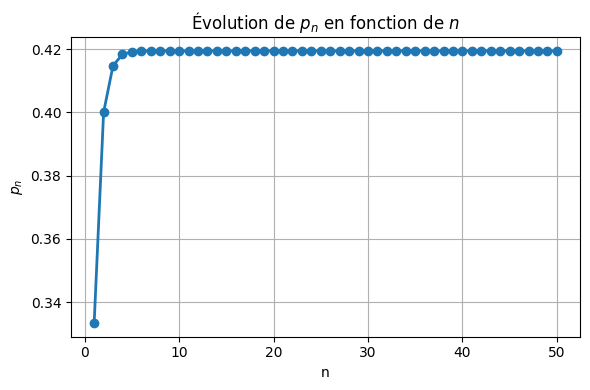

In [53]:
ns = np.arange(1, 50 + 1, 1)
ps = [p_n(n) for n in ns]

plt.figure(figsize=(6, 4))
plt.plot(ns, ps, marker="o", linewidth=2)
plt.xlabel("n")
plt.ylabel("$p_n$")
plt.title("Évolution de $p_n$ en fonction de $n$")
plt.grid(True)
plt.tight_layout()

In [54]:
n = 5 #Simulation for n=5
qc = build_prepare_select_prepare_dag(n)

sim = AerSimulator()
qc_meas = qc.copy()
qc_meas.measure_all()

tqc = transpile(qc_meas, sim, optimization_level=1)

# remove measurements → unitary only
qc_u = tqc.remove_final_measurements(inplace=False)

print("=== Decomposed circuit metrics ===")
print(f"Num qubits: {qc_u.num_qubits}")
print(f"Gate count (size): {qc_u.size()}")
print(f"Depth: {qc_u.depth()}")
print("Ops:", qc_u.count_ops())

=== Decomposed circuit metrics ===
Num qubits: 16
Gate count (size): 250
Depth: 187
Ops: OrderedDict({'ccx': 128, 'x': 80, 'cx': 22, 'u3': 8, 'h': 5, 'ccz': 5, 'ry': 2})


***EXACT STATEVECTOR ANALYSIS***

In [55]:
sv = Statevector.from_instruction(qc_u)

n_q   = n + 1 # q + flag
n_b   = n
n_anc = n
n_tot = qc_u.num_qubits

keep = []
success_prob = 0.0

for i, amp in enumerate(sv.data):
    if abs(amp) < 1e-12:
        continue

    bits = f"{i:0{n_tot}b}"

    #post-select b = 0^n AND flag = 0
    q_bits = bits[-n_q:]

    if q_bits != "0"*n_q:
        continue

    b_bits = bits[-(n_q + n_b):-n_q]
    keep.append((int(b_bits, 2), amp))
    success_prob += abs(amp)**2

pairs = sorted(keep, key=lambda x: x[0])

print(f"\nSuccess probability (SV) = {success_prob:.6f}")


Success probability (SV) = 0.399731


***SAMPLING***

In [56]:
shots = 20_000
res = sim.run(tqc, shots=shots).result()
counts = res.get_counts()
total = sum(counts.values())

filtered = {}

for bits, ct in counts.items():
    q_bits = bits[-n_q:]

    if q_bits != "0"*n_q:
        continue

    b_bits = bits[-(n_q + n_b):-n_q]
    filtered[b_bits] = filtered.get(b_bits, 0) + ct

kept = sum(filtered.values())

print("\nShot results (post-selected):")
for k in sorted(filtered, key=lambda s: int(s, 2)):
    print(f"{int(k,2):02d}: {filtered[k]}")

emp_success_prob = kept / total

print(f"\nEmpirical success probability ≈ {emp_success_prob:.6f}")


Shot results (post-selected):
00: 635
01: 578
02: 566
03: 526
04: 474
05: 502
06: 457
07: 436
08: 381
09: 371
10: 334
11: 329
12: 281
13: 253
14: 233
15: 223
16: 198
17: 164
18: 181
19: 173
20: 140
21: 106
22: 97
23: 91
24: 79
25: 55
26: 57
27: 46
28: 42
29: 24
30: 30
31: 16

Empirical success probability ≈ 0.403900


***PLOT |amp| vs shots***

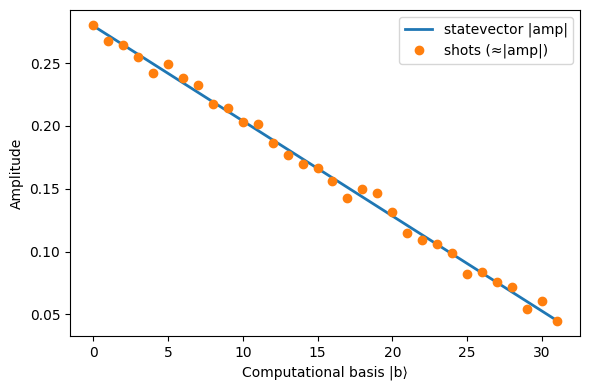

In [64]:
xs = [idx for idx, _ in pairs]

#Multiplying by 1/sqrt(p_success) to renormalize amplitudes after post-selection
ys = [abs(amp)*(1/success_prob**0.5) for _, amp in pairs]
ys_s = [
    np.sqrt(filtered.get(f"{x:0{n_b}b}", 0) / total)*(1/emp_success_prob**0.5)
    for x in xs
]

plt.figure(figsize=(6, 4))
plt.plot(xs, ys, "-", label="statevector |amp|", linewidth=2)
plt.plot(xs, ys_s, "o", label="shots (≈|amp|)")
plt.xlabel("Computational basis |b⟩")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

***Comparison with theoritical amp***

In [60]:
pn = p_n(n)
print("p_n : ",pn)

amp_with_pn_estimation = [(1-(2*pn*i)/(2**n-1))/2**(n/2) for i in range(len(ys))]
normalization_coeff = sum([amp**2 for amp in amp_with_pn_estimation])**0.5
print("normalization_coeff : ",normalization_coeff)
theoritical_amps = [amp/normalization_coeff for amp in amp_with_pn_estimation]

print('amps with sampling method :',ys_s)
print('amps with statevector analysis :',ys)
print("Theoritical amps with pn estimation :", theoritical_amps)

p_n :  0.4191457054202153
normalization_coeff :  0.6322427413473676
amps with sampling method : [np.float64(0.28037219276677694), np.float64(0.26749273718485367), np.float64(0.2647014322397215), np.float64(0.255176659408357), np.float64(0.24223519679636157), np.float64(0.24928717390398947), np.float64(0.237851653893173), np.float64(0.2323225255548165), np.float64(0.21717536666507653), np.float64(0.21430634546222058), np.float64(0.20333929289894448), np.float64(0.20181155305451132), np.float64(0.18650961926595733), np.float64(0.1769735391878303), np.float64(0.16983454657751731), np.float64(0.16615006178287473), np.float64(0.15655994883305427), np.float64(0.14248527981549544), np.float64(0.14968813002825007), np.float64(0.14634272146835337), np.float64(0.1316473415239719), np.float64(0.11455156007589225), np.float64(0.10958066778933556), np.float64(0.10613747992445477), np.float64(0.09889210498229205), np.float64(0.08251433811197867), np.float64(0.08400120255213908), np.float64(0.0754617

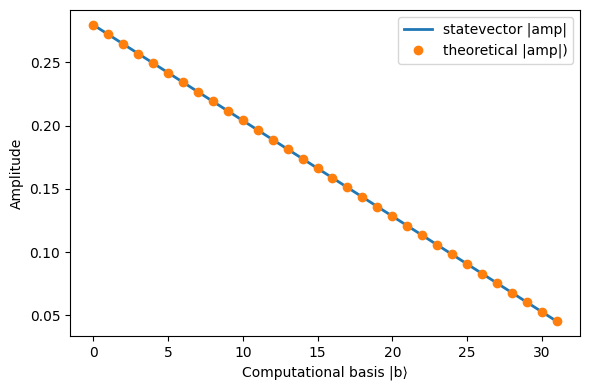

In [68]:
plt.figure(figsize=(6, 4))
plt.plot(xs, ys, "-", label="statevector |amp|", linewidth=2)
plt.plot(xs, theoritical_amps, "o", label="theoretical |amp|)")
plt.xlabel("Computational basis |b⟩")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()